0 1.5720174312591553 0.5510122776031494
Stopping


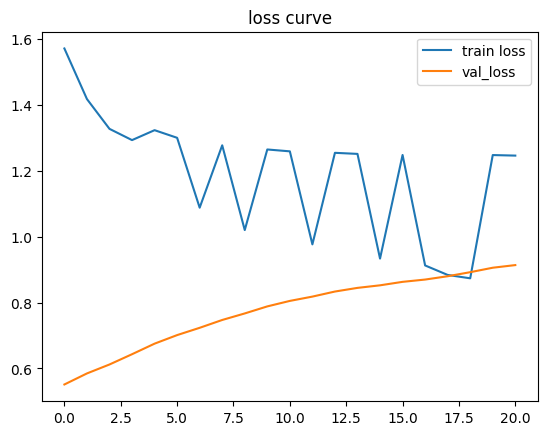

In [2]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader,random_split
import  matplotlib.pyplot as plt
X=torch.tensor([
    [1,2],
    [2,1],
    [3,4],
    [4,3]
],dtype=torch.float32)
Y=torch.tensor([
    [0.0],
    [0.0],
    [1.0],
    [1.0]
])
dataset=TensorDataset(X,Y)
train_size=int(0.75*len(dataset))
val_size=len(dataset)-train_size
train_set,val_set=random_split(dataset,[train_size,val_size])
train_loader=DataLoader(train_set,batch_size=2,shuffle=True)
val_loader=DataLoader(val_set,batch_size=2)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(2,4)
        self.fc2=nn.Linear(4,1)
    def forward(self,X):
        X=self.fc1(X)
        X=torch.relu(X)
        X=self.fc2(X)
        return X
model=Net()
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)
train_losses=[]
val_losses=[]
epochs=200
best_val_loss=float("inf")
patience=20
counter=0
for epoch in range(epochs):
    model.train()
    train_loss=0
    for X_batch,Y_batch in train_loader:
        pred=model(X_batch)
        loss=criterion(pred,Y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()
    model.eval()
    val_loss=0
    with torch.no_grad():
        for X_val,Y_val in val_loader:
            pred=model(X_val)
            loss=criterion(pred,Y_val)
            val_loss+=loss.item()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss=val_loss
        counter=0
    else:
        counter+=1
    if counter >= patience:
        print("Stopping")
        break
    if epoch % 20 ==0:
        print(epoch,train_loss,val_loss)
plt.plot(train_losses,label="train loss")
plt.plot(val_losses,label="val_loss")
plt.legend()
plt.title("loss curve")
plt.show()
        